In [1]:
%reload_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np

import dill
from tqdm import tqdm
import os

from analyze.report import plot_sound, POPULATION_COLORS, draw_spikes_and_psth_bothside, draw_rate_vs_cue, plot_tonotopic_heatmaps
from utils.custom_sounds import Tone, Click_Train, WhiteNoise
import brian2 as b2
import brian2hears as b2h

2026-07-17 09:44:34,336 [INFO ]  

>>>>> start execution
✅ Using local cochlea package from: /Users/francescodesantis/Documents/repos/sound_localization_model/external/cochlea-1



How to cite *cochlea*:

Rudnicki M. and Hemmert W. (2009—). Cochlea: inner ear models in
Python.  https://github.com/mrkrd/cochlea/

@Misc{Rudnicki2009-Cochlea,
  author       = {Rudnicki, M. and Hemmert, W.},
  title        = {Cochlea: inner ear models in Python},
  year         = {2009--},
  howpublished = {https://github.com/mrkrd/cochlea},
  url          = {https://github.com/mrkrd/cochlea},
}



## LSO ILD

In [2]:
folder_dir = '/Users/francescodesantis/Library/CloudStorage/OneDrive-PolitecnicodiMilano/work/sound_localization/results/artificial_ild/we_5_wi_-80/d_0.78/'
# '/Users/francescodesantis/Documents/repos/sound_localization_model/results/artificial_itd/'
# '/Users/francescodesantis/Desktop/cineca_results/'

# List directory contents
items = os.listdir(folder_dir)
items = sorted(items)
for i, item in enumerate(items):
    print(i, item)


0 .DS_Store
1 ataxia
2 tone_11.kHz_59dB&d_0.78_seed_0.pic
3 tone_11.kHz_59dB&d_0.78_seed_1.pic
4 tone_11.kHz_59dB&d_0.78_seed_10.pic
5 tone_11.kHz_59dB&d_0.78_seed_11.pic
6 tone_11.kHz_59dB&d_0.78_seed_12.pic
7 tone_11.kHz_59dB&d_0.78_seed_13.pic
8 tone_11.kHz_59dB&d_0.78_seed_14.pic
9 tone_11.kHz_59dB&d_0.78_seed_15.pic
10 tone_11.kHz_59dB&d_0.78_seed_16.pic
11 tone_11.kHz_59dB&d_0.78_seed_17.pic
12 tone_11.kHz_59dB&d_0.78_seed_18.pic
13 tone_11.kHz_59dB&d_0.78_seed_19.pic
14 tone_11.kHz_59dB&d_0.78_seed_2.pic
15 tone_11.kHz_59dB&d_0.78_seed_20.pic
16 tone_11.kHz_59dB&d_0.78_seed_3.pic
17 tone_11.kHz_59dB&d_0.78_seed_4.pic
18 tone_11.kHz_59dB&d_0.78_seed_5.pic
19 tone_11.kHz_59dB&d_0.78_seed_6.pic
20 tone_11.kHz_59dB&d_0.78_seed_7.pic
21 tone_11.kHz_59dB&d_0.78_seed_8.pic
22 tone_11.kHz_59dB&d_0.78_seed_9.pic
23 tone_12.kHz_59dB&d_0.78_seed_0.pic
24 tone_12.kHz_59dB&d_0.78_seed_1.pic
25 tone_12.kHz_59dB&d_0.78_seed_10.pic
26 tone_12.kHz_59dB&d_0.78_seed_11.pic
27 tone_12.kHz_59dB&d_0.

In [3]:
id_items = range(107,125)
results = []

for i, id in enumerate(id_items):
    file_name = items[id]
    result_path = folder_dir +  file_name 

    with open(result_path, "rb") as file:
        result = dill.load(file, ignore=True)
    print(f"{file_name} loaded")
    results.append(result)


tone_16.kHz_59dB&d_0.78_seed_0.pic loaded
tone_16.kHz_59dB&d_0.78_seed_1.pic loaded
tone_16.kHz_59dB&d_0.78_seed_10.pic loaded
tone_16.kHz_59dB&d_0.78_seed_11.pic loaded
tone_16.kHz_59dB&d_0.78_seed_12.pic loaded
tone_16.kHz_59dB&d_0.78_seed_13.pic loaded
tone_16.kHz_59dB&d_0.78_seed_14.pic loaded
tone_16.kHz_59dB&d_0.78_seed_15.pic loaded
tone_16.kHz_59dB&d_0.78_seed_16.pic loaded
tone_16.kHz_59dB&d_0.78_seed_17.pic loaded
tone_16.kHz_59dB&d_0.78_seed_18.pic loaded
tone_16.kHz_59dB&d_0.78_seed_19.pic loaded
tone_16.kHz_59dB&d_0.78_seed_2.pic loaded
tone_16.kHz_59dB&d_0.78_seed_20.pic loaded
tone_16.kHz_59dB&d_0.78_seed_3.pic loaded
tone_16.kHz_59dB&d_0.78_seed_7.pic loaded
tone_16.kHz_59dB&d_0.78_seed_8.pic loaded
tone_16.kHz_59dB&d_0.78_seed_9.pic loaded


In [4]:
pop = 'LSO'
x_ax = 'ild'
f = 16000
cue_values = np.asarray(list(result['cue_to_rate'].keys()))

[draw_rate_vs_cue] target_cf_hz=16000 Hz → neuron idx 5307 → cf_interval=[15999.0, 15999.2] Hz


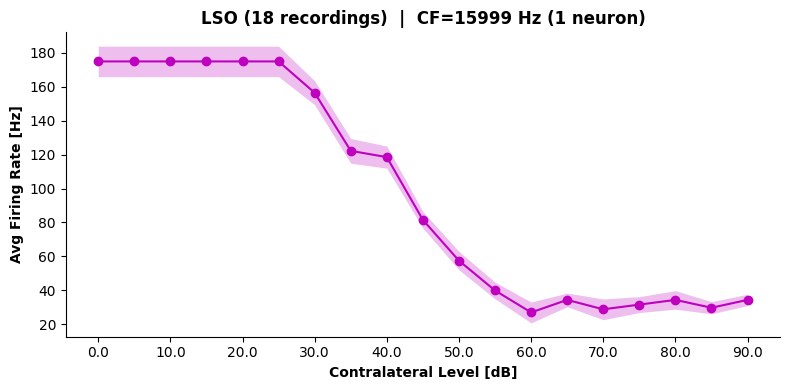

<Axes: title={'center': 'LSO (18 recordings)  |  CF=15999 Hz (1 neuron)'}, xlabel='Contralateral Level [dB]', ylabel='Avg Firing Rate [Hz]'>

In [5]:
from analyze.report import draw_rate_vs_cue

draw_rate_vs_cue(
    data=results,
    pop= pop,
    rate = 'avg',
    side = 'L',
    cue_type = x_ax,
    target_cf_hz = f,
    title = [],
    label = [],
    figsize=[8,4],
    )

175.0 Hz
17.7 dB


<Axes: title={'center': 'R² = 0.993'}, xlabel='ILD (dB)', ylabel='Firing Rate (%)'>

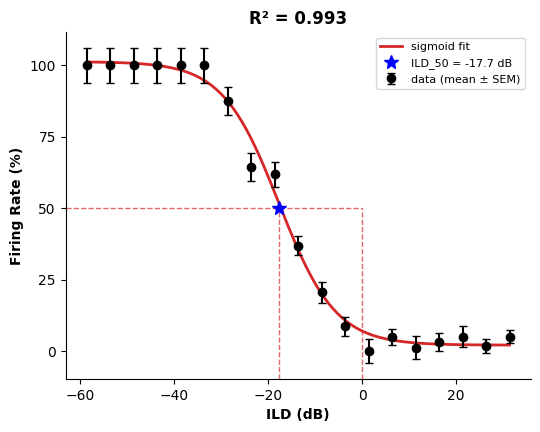

In [6]:
from analyze.report import get_avg_rate_vs_cue, extract_ild50_metrics, plot_ild50_fit_xpaper

curve = get_avg_rate_vs_cue(results, pop='LSO', side='L', center_cf=f, bw_neurons=0)
ipsi_level = results[0]['sounds']['left_sounds'][90.0].level
metrics = extract_ild50_metrics(curve["cues"], curve["rate"], ipsi_ref='min', normalize=False)
print(metrics['max_rate'], "Hz")
print(round(ipsi_level - metrics['ild50']*b2h.dB,2), "dB")
plot_ild50_fit_xpaper(metrics, sem=curve["sem"], ipsi_level = ipsi_level)

[draw_single_neuron_raster_by_cue] pop=LSO side=L → neuron idx=5307, GID=164608, CF=15999.1 Hz


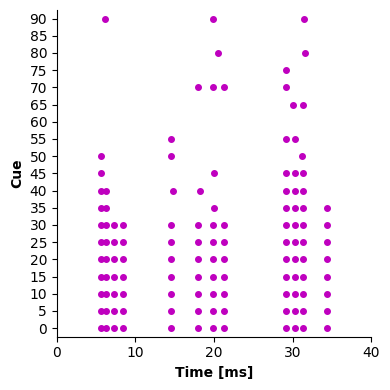

In [7]:
from analyze.report import draw_single_neuron_raster_by_cue_xpaper

fig, axes = draw_single_neuron_raster_by_cue_xpaper(
    results[3], pop='LSO', side='L', target_cf_hz=f,figsize = [4,4], xlim = [0,40],
)


In [8]:
import re

freqs = [11000, 12000, 13000, 14000, 15000, 16000, 17000, 18000, 19000, 19900]

def freq_to_str(f):
    # matches "11", "19.9" etc. as they appear in filenames
    return f"{f/1000:g}"

array = []
for f in freqs[:-1]:
    fstr = freq_to_str(f)
    pattern = re.compile(rf"^tone_{re.escape(fstr)}.kHz")
    matching_files = [it for it in items if pattern.match(it)]
    
    results = []
    for file_name in matching_files:
        result_path = folder_dir + file_name
        with open(result_path, "rb") as file:
            result = dill.load(file, ignore=True)
        print(f"{file_name} loaded")
        results.append(result)
    
    array.append(results)

fstr = freq_to_str(19900)
pattern = re.compile(rf"^tone_{re.escape(fstr)}kHz")
matching_files = [it for it in items if pattern.match(it)]
results = []
for file_name in matching_files:
    result_path = folder_dir + file_name
    with open(result_path, "rb") as file:
        result = dill.load(file, ignore=True)
    print(f"{file_name} loaded")
    results.append(result)

array.append(results)


tone_11.kHz_59dB&d_0.78_seed_0.pic loaded
tone_11.kHz_59dB&d_0.78_seed_1.pic loaded
tone_11.kHz_59dB&d_0.78_seed_10.pic loaded
tone_11.kHz_59dB&d_0.78_seed_11.pic loaded
tone_11.kHz_59dB&d_0.78_seed_12.pic loaded
tone_11.kHz_59dB&d_0.78_seed_13.pic loaded
tone_11.kHz_59dB&d_0.78_seed_14.pic loaded
tone_11.kHz_59dB&d_0.78_seed_15.pic loaded
tone_11.kHz_59dB&d_0.78_seed_16.pic loaded
tone_11.kHz_59dB&d_0.78_seed_17.pic loaded
tone_11.kHz_59dB&d_0.78_seed_18.pic loaded
tone_11.kHz_59dB&d_0.78_seed_19.pic loaded
tone_11.kHz_59dB&d_0.78_seed_2.pic loaded
tone_11.kHz_59dB&d_0.78_seed_20.pic loaded
tone_11.kHz_59dB&d_0.78_seed_3.pic loaded
tone_11.kHz_59dB&d_0.78_seed_4.pic loaded
tone_11.kHz_59dB&d_0.78_seed_5.pic loaded
tone_11.kHz_59dB&d_0.78_seed_6.pic loaded
tone_11.kHz_59dB&d_0.78_seed_7.pic loaded
tone_11.kHz_59dB&d_0.78_seed_8.pic loaded
tone_11.kHz_59dB&d_0.78_seed_9.pic loaded
tone_12.kHz_59dB&d_0.78_seed_0.pic loaded
tone_12.kHz_59dB&d_0.78_seed_1.pic loaded
tone_12.kHz_59dB&d_0.78

In [9]:
len(array)

10

[draw_rate_vs_cue_multidata] group '11.0, kHz': target_cf_hz=11000 Hz → neuron idx 4818 → cf_interval=[10996.0, 10996.2] Hz
[draw_rate_vs_cue_multidata] group '12.0, kHz': target_cf_hz=12000 Hz → neuron idx 4932 → cf_interval=[12002.5, 12002.7] Hz
[draw_rate_vs_cue_multidata] group '13.0, kHz': target_cf_hz=13000 Hz → neuron idx 5036 → cf_interval=[12999.7, 12999.9] Hz
[draw_rate_vs_cue_multidata] group '14.0, kHz': target_cf_hz=14000 Hz → neuron idx 5133 → cf_interval=[14003.2, 14003.4] Hz
[draw_rate_vs_cue_multidata] group '15.0, kHz': target_cf_hz=15000 Hz → neuron idx 5223 → cf_interval=[15002.7, 15002.9] Hz
[draw_rate_vs_cue_multidata] group '16.0, kHz': target_cf_hz=16000 Hz → neuron idx 5307 → cf_interval=[15999.0, 15999.2] Hz
[draw_rate_vs_cue_multidata] group '17.0, kHz': target_cf_hz=17000 Hz → neuron idx 5386 → cf_interval=[16995.7, 16995.9] Hz
[draw_rate_vs_cue_multidata] group '18.0, kHz': target_cf_hz=18000 Hz → neuron idx 5461 → cf_interval=[17998.7, 17998.9] Hz
[draw_ra

(<Figure size 700x400 with 1 Axes>,
 <Axes: title={'center': 'LSO — side L (10 groups)'}, xlabel='ILD [dB]', ylabel='Avg Firing Rate [Hz]'>)

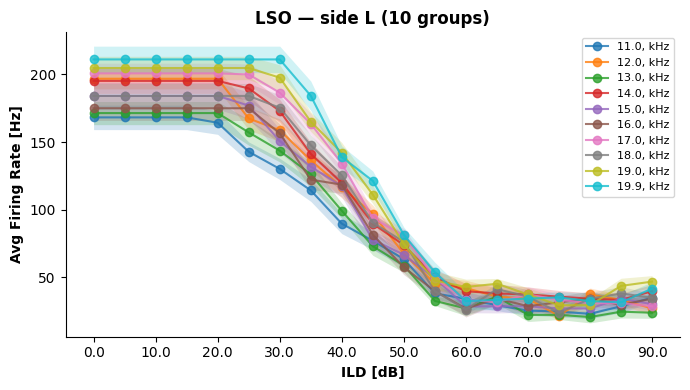

In [17]:
from analyze.report import draw_rate_vs_cue_multidata

draw_rate_vs_cue_multidata(
    data_list= array,
    pop= pop,
    side='L',
    rate = 'avg',
    cue_type = x_ax,
    target_cf_hz = [f for f in freqs[:]],
    labels = [f"{f/1000}, kHz" for f in freqs[:]],
)

ILD50 (normalized to population max):
  11.00 kHz -> ILD50 = 20.07 dB
  12.00 kHz -> ILD50 = 18.66 dB
  13.00 kHz -> ILD50 = 18.33 dB
  14.00 kHz -> ILD50 = 18.11 dB
  15.00 kHz -> ILD50 = 18.08 dB
  16.00 kHz -> ILD50 = 17.70 dB
  17.00 kHz -> ILD50 = 16.02 dB
  18.00 kHz -> ILD50 = 16.12 dB
  19.00 kHz -> ILD50 = 15.77 dB
  19.90 kHz -> ILD50 = 14.82 dB

AVERAGE ILD50 (normalized): 17.37 dB


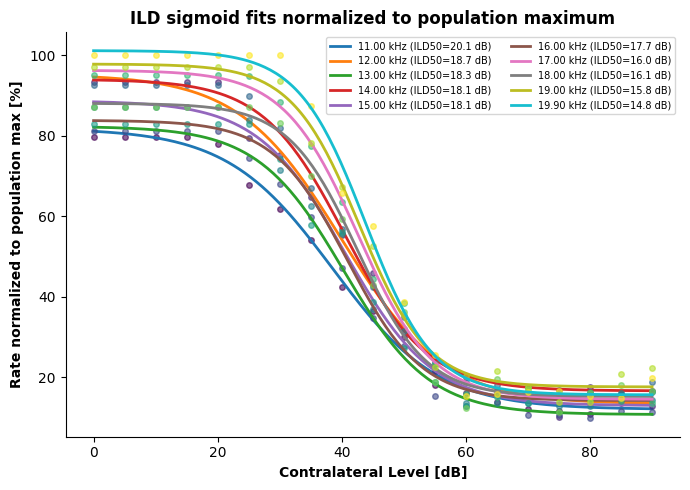

In [ ]:
from analyze.report import extract_first_spike_latency_metrics

freq_array = []
max_rate_array = []
min_rate_array = []
ild50_array = []
first_spike_latency_array = []
jitter_array = []
raw_curves = []

for i in range(len(array)):
    results = array[i]
    f = results[0]['sounds']['base_sound'].frequency / b2.Hz
    curve = get_avg_rate_vs_cue(results, pop='LSO', side='L', center_cf=f, bw_neurons=0)
    metrics = extract_ild50_metrics(curve["cues"], curve["rate"], ipsi_ref='min', normalize=False)
    metrics_fsl = extract_first_spike_latency_metrics(
        results, pop='LSO', side='L', cue=0, center_cf=f, onset_time=.0, window=[5.0, 25.0]
    )
    ipsi_level = results[0]['sounds']['left_sounds'][90.0].level
    ild50_db = ipsi_level - metrics["ild50"] * b2h.dB

    freq_array.append(f)
    min_rate_array.append(metrics["min_rate"])
    max_rate_array.append(metrics["max_rate"])
    ild50_array.append(ild50_db)
    first_spike_latency_array.append(metrics_fsl["median_latency"])
    jitter_array.append(metrics_fsl["jitter_iqr"])
    raw_curves.append(curve)

# --- normalize all curves to the max of maxima across the population ---
pop_max = np.mean(max_rate_array)

metrics_norm_array = []
ild50_norm_array = []
ipsi_levels = []

for i in range(len(array)):
    results = array[i]
    curve = raw_curves[i]
    rate_norm = curve["rate"] / pop_max * 100.0

    metrics_norm = extract_ild50_metrics(
        curve["cues"], rate_norm, ipsi_ref='min', normalize=False
    )
    ipsi_level = results[0]['sounds']['left_sounds'][90.0].level
    ild50_db_norm = ipsi_level - metrics_norm["ild50"] * b2h.dB

    metrics_norm_array.append(metrics_norm)
    ild50_norm_array.append(ild50_db_norm)
    ipsi_levels.append(ipsi_level)

print("ILD50 (normalized to population max):")
for f, ild in zip(freq_array, ild50_norm_array):
    print(f"  {f/1000:.2f} kHz -> ILD50 = {ild:.2f} dB")

ild50_norm_avg = np.mean(ild50_norm_array)
print(f"\nAVERAGE ILD50 (normalized): {ild50_norm_avg:.2f} dB")

# --- plot all normalized sigmoid fits together ---
fig, ax = plt.subplots(figsize=(7, 5))
cmap = plt.cm.viridis(np.linspace(0, 1, len(array)))

for i in range(len(array)):
    curve = raw_curves[i]
    metrics_norm = metrics_norm_array[i]
    fit_fn = metrics_norm["fit_curve_fn"]

    x_fit = np.linspace(curve["cues"].min(), curve["cues"].max(), 200)
    y_fit = fit_fn(x_fit)

    ax.plot(curve["cues"], metrics_norm["rate"], 'o', color=cmap[i], ms=4, alpha=0.6)
    ax.plot(x_fit, y_fit, '-', lw=2,
            label=f"{freq_array[i]/1000:.2f} kHz (ILD50={ild50_norm_array[i]:.1f} dB)")

ax.set_xlabel("Contralateral Level [dB]")
ax.set_ylabel("Rate normalized to population max [%]")
ax.set_title("ILD sigmoid fits normalized to population maximum")
ax.legend(loc='best', fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

## LSO ITD

In [11]:
folder_dir = '/Users/francescodesantis/Library/CloudStorage/OneDrive-PolitecnicodiMilano/work/sound_localization/results/artificial_itd/LSO/we_1_wi_-2.3/d_0.78/'
# '/Users/francescodesantis/Documents/repos/sound_localization_model/results/artificial_itd/'
# '/Users/francescodesantis/Desktop/cineca_results/'

# List directory contents
items = os.listdir(folder_dir)
items = sorted(items)
for i, item in enumerate(items):
    print(i, item)


0 click_train_interval_5. ms_70dB&d0.78_seed0_multimeters.pic
1 click_train_interval_5. ms_70dB&seed0.pic
2 click_train_interval_5. ms_70dB&seed1.pic
3 click_train_interval_5. ms_70dB&seed10.pic
4 click_train_interval_5. ms_70dB&seed11.pic
5 click_train_interval_5. ms_70dB&seed12.pic
6 click_train_interval_5. ms_70dB&seed13.pic
7 click_train_interval_5. ms_70dB&seed14.pic
8 click_train_interval_5. ms_70dB&seed15.pic
9 click_train_interval_5. ms_70dB&seed16.pic
10 click_train_interval_5. ms_70dB&seed17.pic
11 click_train_interval_5. ms_70dB&seed18.pic
12 click_train_interval_5. ms_70dB&seed19.pic
13 click_train_interval_5. ms_70dB&seed2.pic
14 click_train_interval_5. ms_70dB&seed3.pic
15 click_train_interval_5. ms_70dB&seed4.pic
16 click_train_interval_5. ms_70dB&seed5.pic
17 click_train_interval_5. ms_70dB&seed6.pic


In [12]:
id_items = range(1,18)
results = []

for i, id in enumerate(id_items):
    file_name = items[id]
    result_path = folder_dir +  file_name 

    with open(result_path, "rb") as file:
        result = dill.load(file, ignore=True)
    print(f"{file_name} loaded")
    results.append(result)


KeyboardInterrupt: 

In [ ]:
pop = 'LSO'
x_ax = 'itd'
f = 14000
cue_values = np.asarray(list(result['cue_to_rate'].keys()))

[draw_rate_vs_cue] target_cf_hz=14000 Hz → neuron idx 5133 → cf_interval=[14003.2, 14003.4] Hz


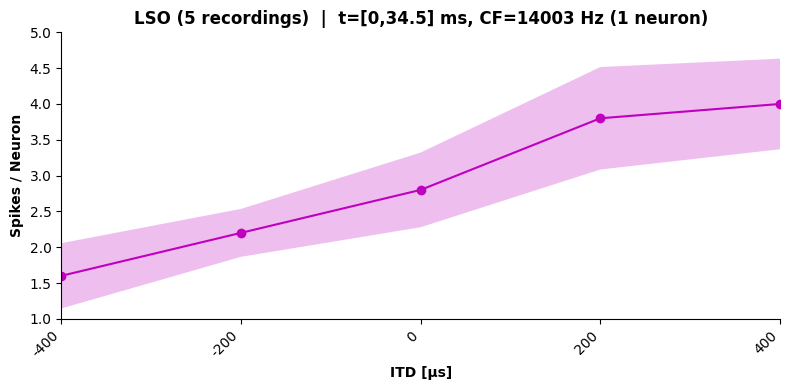

<Axes: title={'center': 'LSO (5 recordings)  |  t=[0,34.5] ms, CF=14003 Hz (1 neuron)'}, xlabel='ITD [µs]', ylabel='Spikes / Neuron'>

In [ ]:
from analyze.report import draw_rate_vs_cue

draw_rate_vs_cue(
    data=results,
    pop= pop,
    rate = 'spk_pn',
    side = 'L',
    cue_type = x_ax,
    target_cf_hz = f,
    xlim = [-400,400],
    ylim = [1,5],
    title = [],
    label = [],
    figsize=[8,4],
    time_interval=[0,34.5]
    )

[draw_single_neuron_raster] pop=LSO side=L → neuron idx=5133, GID=164434, CF=14003.3 Hz
[draw_single_neuron_raster] pop=LSO side=L → neuron idx=5133, GID=164434, CF=14003.3 Hz
[draw_single_neuron_raster] pop=LSO side=L → neuron idx=5133, GID=164434, CF=14003.3 Hz
[draw_single_neuron_raster] pop=LSO side=L → neuron idx=5133, GID=164434, CF=14003.3 Hz
[draw_single_neuron_raster] pop=LSO side=L → neuron idx=5133, GID=164434, CF=14003.3 Hz


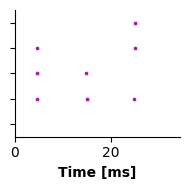

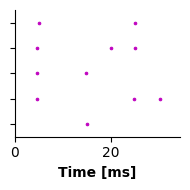

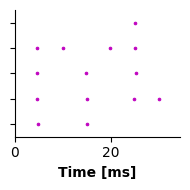

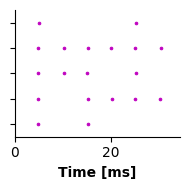

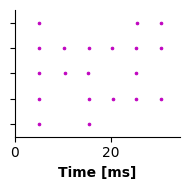

In [ ]:
from analyze.report import draw_single_neuron_raster_xpaper

for i in range(11,16):
    c = cue_values[i]
    draw_single_neuron_raster_xpaper(
        data_list=results,
        cue = c,
        pop = pop,
        side = 'L',
        target_cf_hz= f,
        xlim=[0,34.5],
        figsize=[2,2]
    )

## MSO ITD

In [ ]:
folder_dir = '/Users/francescodesantis/Library/CloudStorage/OneDrive-PolitecnicodiMilano/work/sound_localization/results/artificial_itd/MSO/we_6_wi_-8/'
# '/Users/francescodesantis/Documents/repos/sound_localization_model/results/artificial_itd/'
# '/Users/francescodesantis/Desktop/cineca_results/'

# List directory contents
items = os.listdir(folder_dir)
items = sorted(items)
for i, item in enumerate(items):
    print(i, item)


0 .DS_Store
1 tone_0.4kHz_59dB&d_0.78_seed_0.pic
2 tone_0.4kHz_59dB&d_0.78_seed_1.pic
3 tone_0.4kHz_59dB&d_0.78_seed_10.pic
4 tone_0.4kHz_59dB&d_0.78_seed_11.pic
5 tone_0.4kHz_59dB&d_0.78_seed_12.pic
6 tone_0.4kHz_59dB&d_0.78_seed_13.pic
7 tone_0.4kHz_59dB&d_0.78_seed_14.pic
8 tone_0.4kHz_59dB&d_0.78_seed_15.pic
9 tone_0.4kHz_59dB&d_0.78_seed_16.pic
10 tone_0.4kHz_59dB&d_0.78_seed_17.pic
11 tone_0.4kHz_59dB&d_0.78_seed_18.pic
12 tone_0.4kHz_59dB&d_0.78_seed_19.pic
13 tone_0.4kHz_59dB&d_0.78_seed_2.pic
14 tone_0.4kHz_59dB&d_0.78_seed_20.pic
15 tone_0.4kHz_59dB&d_0.78_seed_3.pic
16 tone_0.4kHz_59dB&d_0.78_seed_4.pic
17 tone_0.4kHz_59dB&d_0.78_seed_5.pic
18 tone_0.4kHz_59dB&d_0.78_seed_6.pic
19 tone_0.4kHz_59dB&d_0.78_seed_7.pic
20 tone_0.4kHz_59dB&d_0.78_seed_8.pic
21 tone_0.4kHz_59dB&d_0.78_seed_9.pic
22 tone_0.6kHz_59dB&d_0.78_seed_0.pic
23 tone_0.6kHz_59dB&d_0.78_seed_1.pic
24 tone_0.6kHz_59dB&d_0.78_seed_10.pic
25 tone_0.6kHz_59dB&d_0.78_seed_11.pic
26 tone_0.6kHz_59dB&d_0.78_seed_12

In [ ]:
import os
import re
from collections import defaultdict

folder_dir = '/Users/francescodesantis/Library/CloudStorage/OneDrive-PolitecnicodiMilano/work/sound_localization/results/artificial_itd/MSO/we_6_wi_-8/'

items = sorted(os.listdir(folder_dir))
items = [f for f in items if f.endswith('.pic')]  # drop .DS_Store etc.

# Regex to pull out the frequency value + unit (kHz or Hz)
pattern = re.compile(r'tone_([\d.]+)(kHz|Hz)_')

freq_to_files = defaultdict(list)

for fname in items:
    m = pattern.search(fname)
    if not m:
        continue
    value, unit = m.groups()
    freq_hz = float(value) * (1000 if unit == 'kHz' else 1)
    freq_to_files[freq_hz].append(fname)

# Sort frequencies ascending
sorted_freqs = sorted(freq_to_files.keys())

# Build the cluster array: each element = list of loaded data for that frequency
cluster = []
for freq in sorted_freqs:
    fnames = sorted(freq_to_files[freq])  # sort seeds within a frequency too
    loaded = []
    for fname in fnames:
        with open(os.path.join(folder_dir, fname), 'rb') as f:
            data = dill.load(f)
        print(f"{fname} loaded")
        loaded.append(data)
    cluster.append(loaded)

# Sanity check
for freq, group in zip(sorted_freqs, cluster):
    print(f"{freq} Hz -> {len(group)} files")

tone_200.Hz_59dB&d_0.78_seed_0.pic loaded
tone_200.Hz_59dB&d_0.78_seed_1.pic loaded
tone_200.Hz_59dB&d_0.78_seed_10.pic loaded
tone_200.Hz_59dB&d_0.78_seed_11.pic loaded
tone_200.Hz_59dB&d_0.78_seed_12.pic loaded
tone_200.Hz_59dB&d_0.78_seed_13.pic loaded


OSError: [Errno 89] Operation canceled

In [ ]:
id_items = range(169,190)
results = []

for i, id in enumerate(id_items):
    file_name = items[id]
    result_path = folder_dir +  file_name 

    with open(result_path, "rb") as file:
        result = dill.load(file, ignore=True)
    print(f"{file_name} loaded")
    results.append(result)


tone_250.Hz_59dB&d_0.78_seed_0.pic loaded
tone_250.Hz_59dB&d_0.78_seed_1.pic loaded
tone_250.Hz_59dB&d_0.78_seed_10.pic loaded
tone_250.Hz_59dB&d_0.78_seed_11.pic loaded
tone_250.Hz_59dB&d_0.78_seed_12.pic loaded
tone_250.Hz_59dB&d_0.78_seed_13.pic loaded
tone_250.Hz_59dB&d_0.78_seed_14.pic loaded
tone_250.Hz_59dB&d_0.78_seed_15.pic loaded
tone_250.Hz_59dB&d_0.78_seed_16.pic loaded
tone_250.Hz_59dB&d_0.78_seed_17.pic loaded
tone_250.Hz_59dB&d_0.78_seed_18.pic loaded
tone_250.Hz_59dB&d_0.78_seed_19.pic loaded
tone_250.Hz_59dB&d_0.78_seed_2.pic loaded
tone_250.Hz_59dB&d_0.78_seed_20.pic loaded
tone_250.Hz_59dB&d_0.78_seed_3.pic loaded
tone_250.Hz_59dB&d_0.78_seed_4.pic loaded
tone_250.Hz_59dB&d_0.78_seed_5.pic loaded
tone_250.Hz_59dB&d_0.78_seed_6.pic loaded
tone_250.Hz_59dB&d_0.78_seed_7.pic loaded
tone_250.Hz_59dB&d_0.78_seed_8.pic loaded
tone_250.Hz_59dB&d_0.78_seed_9.pic loaded


In [ ]:
pop = 'MSO'
x_ax = 'itd'
f = 250
cue_values = np.asarray(list(result['cue_to_rate'].keys()))

[draw_rate_vs_cue] center_cf=250 Hz → neuron idx [1298, 1318] → cf_interval=[248.8, 251.1] Hz


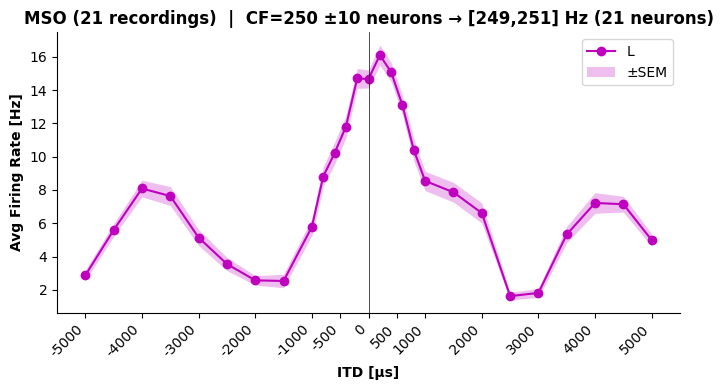

<Axes: title={'center': 'MSO (21 recordings)  |  CF=250 ±10 neurons → [249,251] Hz (21 neurons)'}, xlabel='ITD [µs]', ylabel='Avg Firing Rate [Hz]'>

In [ ]:
from analyze.report import draw_rate_vs_cue

draw_rate_vs_cue(
    data=results,
    pop= pop,
    rate = 'avg',
    side = 'L',
    cue_type = x_ax,
    center_cf = f,
    bw_neurons=10
    )

In [ ]:
from analyze.report import get_avg_rate_vs_cue, extract_best_itd_ipd, plot_best_itd_ipd_vs_freq

if pop == 'MSO':
    max_itds = []
    bws = [10,10,10,10,10,10,10,10,10,10]
    for i, bw in enumerate(bws):
        f = array[i][0]['sounds']['base_sound'].frequency / b2.Hz

        draw_rate_vs_cue(
            data=array[i],
            pop= pop,
            side = 'L',
            rate = 'avg',
            cue_type = x_ax,
            # target_cf_hz = f,
            center_cf = f,
            bw_neurons = bw,
        )

        curve = get_avg_rate_vs_cue(array[i], pop='MSO', side='L', center_cf=f, bw_neurons=10, rate='avg')
        print(extract_best_itd_ipd(curve, f))
        max_itds.append(extract_best_itd_ipd(curve, f))
        print(f"max rate: {np.max(curve['rate'])} at cue: {curve['cues'][np.argmax(curve['rate'])]}")

    plot_best_itd_ipd_vs_freq(max_itds)